In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. Load data
data_path = r"C:\Users\hp\Desktop\Kifya\Time-Series-Forecasting-for-Portfolio-Management-Optimization\portfolio-optimization\data\processed\cleaned_financial_data.csv"
data = pd.read_csv(data_path, index_col=0, parse_dates=True)

# 2. Define the Backtesting Period (Last 12 months)
# Assuming your data ends in early 2026, we take 2025 onwards
test_data = data.loc['2025-01-01':]
test_returns = test_data.pct_change().dropna()

print(f"Backtesting from {test_returns.index[0].date()} to {test_returns.index[-1].date()}")

Backtesting from 2025-01-03 to 2026-01-14


In [2]:
# --- Your Strategy (From Task 4) ---
# Weights: BND: 59.27%, SPY: 31.37%, TSLA: 9.36%
strat_weights = np.array([0.5927, 0.3137, 0.0936])
strat_daily_ret = test_returns.dot(strat_weights)
strat_cumulative = (1 + strat_daily_ret).cumprod()

# --- The Benchmark (60/40) ---
# Weights: BND: 40%, SPY: 60%, TSLA: 0%
bench_weights = np.array([0.40, 0.60, 0.00])
bench_daily_ret = test_returns.dot(bench_weights)
bench_cumulative = (1 + bench_daily_ret).cumprod()

In [3]:
def calculate_metrics(daily_returns, cumulative_returns):
    total_return = cumulative_returns.iloc[-1] - 1
    ann_return = daily_returns.mean() * 252
    ann_vol = daily_returns.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol
    
    # Max Drawdown (The biggest drop from a peak)
    peak = cumulative_returns.cummax()
    drawdown = (cumulative_returns - peak) / peak
    max_drawdown = drawdown.min()
    
    return [total_return, ann_return, sharpe, max_drawdown]

strat_metrics = calculate_metrics(strat_daily_ret, strat_cumulative)
bench_metrics = calculate_metrics(bench_daily_ret, bench_cumulative)

# Create the Deliverable Table
metrics_df = pd.DataFrame({
    "Metric": ["Total Return", "Annualized Return", "Sharpe Ratio", "Max Drawdown"],
    "Your AI Strategy": [f"{m:.2%}" if i != 2 else f"{m:.2f}" for i, m in enumerate(strat_metrics)],
    "60/40 Benchmark": [f"{m:.2%}" if i != 2 else f"{m:.2f}" for i, m in enumerate(bench_metrics)]
})

print("\n--- PERFORMANCE METRICS TABLE ---")
print(metrics_df)


--- PERFORMANCE METRICS TABLE ---
              Metric Your AI Strategy 60/40 Benchmark
0       Total Return           14.01%          15.07%
1  Annualized Return           13.45%          14.41%
2       Sharpe Ratio             1.18            1.22
3       Max Drawdown          -10.06%         -11.29%


FileNotFoundError: [Errno 2] No such file or directory: 'data/processed\\backtest_comparison.png'

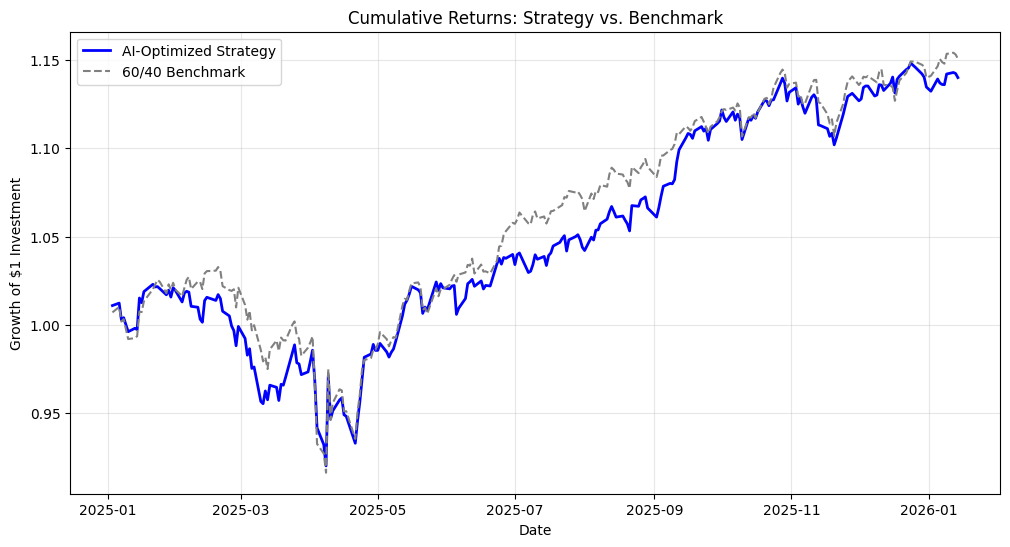

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(strat_cumulative, label="AI-Optimized Strategy", linewidth=2, color='blue')
plt.plot(bench_cumulative, label="60/40 Benchmark", linestyle='--', color='gray')
plt.title("Cumulative Returns: Strategy vs. Benchmark")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")
plt.legend()
plt.grid(True, alpha=0.3)

# Save to your processed folder
output_path = "data/processed"
plt.savefig(os.path.join(output_path, "backtest_comparison.png"), dpi=300)
plt.show()